e:\ViT MLDC\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train: 2800  Val: 600  Test: 600
Extracting features (train with Dual Augmentation)...


100%|██████████| 600/600 [00:12<00:00, 48.83it/s]


Feature shapes:
Train: (2800, 768)
Val  : (600, 768)
Test : (600, 768)
ViTHead(
  (dropout): Dropout(p=0.4, inplace=False)
  (head): LoRALinear(
    (linear): Linear(in_features=768, out_features=8, bias=False)
    (lora_a): Linear(in_features=768, out_features=4, bias=False)
    (lora_b): Linear(in_features=4, out_features=8, bias=False)
  )
)
Epoch 1/50 - Train Loss: 2.0949  Val Loss: 2.0407
Epoch 2/50 - Train Loss: 2.0496  Val Loss: 1.9971
Epoch 3/50 - Train Loss: 2.0029  Val Loss: 1.9548
Epoch 4/50 - Train Loss: 1.9623  Val Loss: 1.9132
Epoch 5/50 - Train Loss: 1.9283  Val Loss: 1.8731
Epoch 6/50 - Train Loss: 1.8791  Val Loss: 1.8340
Epoch 7/50 - Train Loss: 1.8444  Val Loss: 1.7966
Epoch 8/50 - Train Loss: 1.8172  Val Loss: 1.7602
Epoch 9/50 - Train Loss: 1.7702  Val Loss: 1.7253
Epoch 10/50 - Train Loss: 1.7389  Val Loss: 1.6917
Epoch 11/50 - Train Loss: 1.7106  Val Loss: 1.6592
Epoch 12/50 - Train Loss: 1.6787  Val Loss: 1.6283
Epoch 13/50 - Train Loss: 1.6434  Val Loss: 1.5987

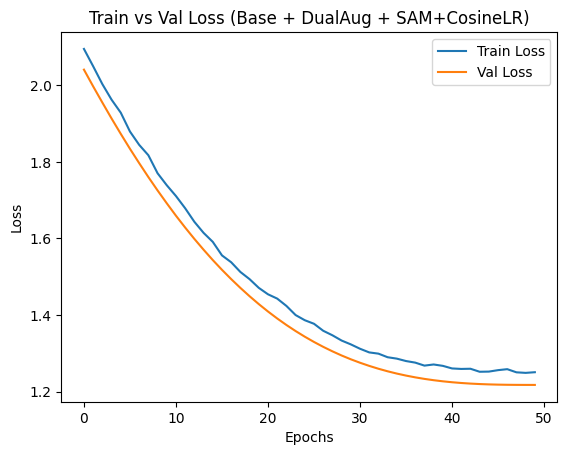


Final Test Metrics (Base + DualAug + SAM + CosineLR):
Accuracy  : 0.8450
Precision : 0.8512
Recall    : 0.8450
F1 Score  : 0.8410


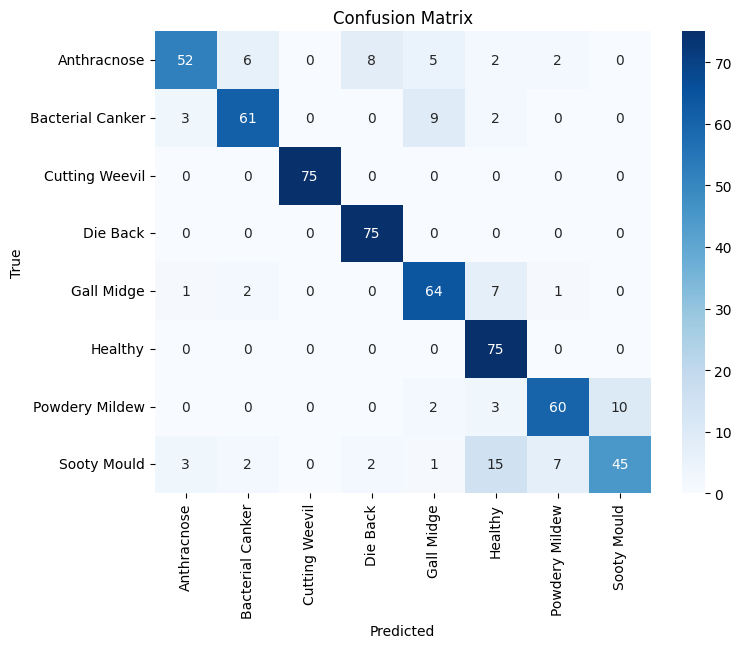

In [1]:
# =========================
# Base + Dual Augmentation + SAM + CosineLR
# =========================

# Imports & Device Setup
import os, glob, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# =========================
# Dataset Paths & Split
# =========================
DATASET_DIR = r"E:\ViT MLDC\dataset"  # <-- update if needed
IMG_SIZE = 224

# Classes
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

# Image paths and labels
image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

# =========================
# Dual Augmentation Transforms
# =========================
train_base = [transforms.Resize((IMG_SIZE, IMG_SIZE))]

dual_aug1 = transforms.RandomChoice([
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05,0.05))
])

dual_aug2 = transforms.RandomChoice([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.9,1.0)),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
])

train_transform = transforms.Compose(train_base + [dual_aug1, dual_aug2,
                                                   transforms.ToTensor(),
                                                   transforms.Normalize([0.5]*3, [0.5]*3)])
val_transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                    transforms.ToTensor(),
                                    transforms.Normalize([0.5]*3, [0.5]*3)])

# =========================
# Feature Extraction (Tiny Swin V2)
# =========================
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

print("Extracting features (train with Dual Augmentation)...")
X_train_feats = np.stack([extract_feature_from_path(p, train_transform) for p in tqdm(X_train_paths)])
X_val_feats   = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats  = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])

print("Feature shapes:")
print("Train:", X_train_feats.shape)
print("Val  :", X_val_feats.shape)
print("Test :", X_test_feats.shape)

# =========================
# LoRA-adapted ViT Head (same as base)
# =========================
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=4):   # rank
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)

    def forward(self, x):
        return self.linear(x) + self.lora_b(self.lora_a(x))


class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes, dropout_rate=0.4):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.head = LoRALinear(in_features, num_classes, r=4)

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.head(self.dropout(x)).squeeze(0)
        return self.head(self.dropout(x))

# Initialize head
in_features = X_train_feats.shape[1]
num_classes = len(CLASS_NAMES)
model_head = ViTHead(in_features, num_classes, dropout_rate=0.4).to(device)
print(model_head)

# =========================
# Dataloaders (augmented features used for training)
# =========================
batch_size = 64
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_feats, dtype=torch.float32),
                                        torch.tensor(y_train, dtype=torch.long)),
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32),
                                      torch.tensor(y_val, dtype=torch.long)),
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32),
                                       torch.tensor(y_test, dtype=torch.long)),
                         batch_size=batch_size, shuffle=False)

# =========================
# SAM + Cosine LR setup
# =========================
try:
    from sam import SAM   # ensure sam.py is in the same folder
except Exception as e:
    raise ImportError("Could not import sam.SAM. Make sure sam.py is available and contains SAM class.") from e

base_optimizer = torch.optim.Adam
optimizer = SAM(model_head.parameters(), base_optimizer, lr=1e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer.base_optimizer, T_max=50)  # T_max = epochs or cycle length

criterion = nn.CrossEntropyLoss()

# =========================
# Training Loop (SAM-compatible)
# =========================
EPOCHS = 50
PATIENCE = 5
best_val_loss = float("inf")
wait = 0
best_model_path = "tinyswin_lora_dualaug_sam.pth"

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model_head.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # --------------------
        # 1) forward-backward (compute gradients at current weights)
        # --------------------
        logits = model_head(xb)
        loss = criterion(logits, yb)
        loss.backward()

        # --------------------
        # 2) SAM first step (climb)
        # --------------------
        optimizer.first_step(zero_grad=True)

        # --------------------
        # 3) second forward-backward at perturbed weights
        # --------------------
        logits2 = model_head(xb)
        loss2 = criterion(logits2, yb)
        loss2.backward()

        # --------------------
        # 4) SAM second step (descent)
        # --------------------
        optimizer.second_step(zero_grad=True)

        total_loss += loss.item() * xb.size(0)

    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation
    model_head.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model_head(xb)
            lossv = criterion(logits, yb)
            val_loss += lossv.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    # step scheduler (using base optimizer)
    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Early Stopping & save best
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model_head.state_dict(), best_model_path)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# =========================
# Plot Losses
# =========================
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train vs Val Loss (Base + DualAug + SAM+CosineLR)")
plt.legend()
plt.show()

# =========================
# Evaluation
# =========================
model_head.load_state_dict(torch.load(best_model_path))
model_head.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model_head(xb)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_true.extend(yb.numpy())
        y_pred.extend(preds)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")

print("\nFinal Test Metrics (Base + DualAug + SAM + CosineLR):")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
